# **EXPERIMENT-9** -AdultIncome Dataset

**AIM**:To implement an Ensemble Learning model using Random Forest Classifier on the Adult Income dataset in order to predict whether a person earns more than 50K per year and to evaluate the model using accuracy, OOB score, confusion matrix and feature importance.

**Random Forest Algorithm –**
  * Random Forest is an ensemble learning algorithm:
  * Combines many decision trees to make predictions.
  * Helps reduce overfitting compared to a single tree.

**Steps in Random Forest:**
  * Take random subsets of the dataset (with replacement → bootstrap).
  * Train a decision tree on each subset.
  * Randomly select a subset of features for splitting at each node.
  * Make predictions with each tree.
  * Combine predictions (majority vote for classification).

**Advantages:**
  * Handles categorical and numerical data well.
  * Reduces overfitting (better generalization than single tree).
  * Can compute feature importance.

**Disadvantages:**
  * Slower with very large datasets.
  * Harder to interpret compared to a single decision tree.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**Load Dataset and Explore**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
adult_data=pd.read_csv('/content/drive/MyDrive/Datasets/adultIncome.csv')

print("shape:\n",adult_data.shape)
print("\nFirst 2 rows:\n",adult_data.head(5))

shape:
 (48842, 15)

First 2 rows:
    age  workclass  fnlwgt     education  educational-num      marital-status  \
0   25    Private  226802          11th                7       Never-married   
1   38    Private   89814       HS-grad                9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm               12  Married-civ-spouse   
3   44    Private  160323  Some-college               10  Married-civ-spouse   
4   18          ?  103497  Some-college               10       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                  ?    Own-child  White  Female             0             0   

  

**Remove Duplicate Rows**

In [ ]:
print("Duplicate rows:",adult_data.duplicated().sum())
adult_data=adult_data.drop_duplicates()
print("Duplicate rows after removal:",adult_data.duplicated().sum())

Duplicate rows: 52
Duplicate rows after removal: 0


**Handle Missing Values**
* In this dataset, missing values are represented as “?” instead of NaN. Since machine learning models cannot handle string-based missing values, we convert them to NaN first.
* Now we fill missing categorical values using mode (most frequent value). This prevents loss of data and maintains dataset size.

In [ ]:
adult_data.replace(["?", " ?"], np.nan, inplace=True)
print("\nMissing values before filling:\n", adult_data.isnull().sum())
for col in ['workclass', 'occupation', 'native-country']:
    adult_data[col].fillna(adult_data[col].mode()[0], inplace=True)
    #inplace=True: Modifies the original adult_data DataFrame directly rather than returning a new, modified copy of it.
print("\n\nMissing values after filling:\n", adult_data.isnull().sum())


Missing values before filling:
 age                   0
workclass          2795
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2805
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      856
income                0
dtype: int64


Missing values after filling:
 age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64


/tmp/ipython-input-510/400514057.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adult_data[col].fillna(adult_data[col].mode()[0], inplace=True)


**Encode Categorical Variables**

Machine learning models cannot understand text values. Therefore, categorical features such as workclass, education, gender, etc., are converted into numeric form using Label Encoding.

In [ ]:
for col in adult_data.columns:
    if adult_data[col].dtype == 'object':
        le = LabelEncoder()
        adult_data[col] = le.fit_transform(adult_data[col])

**Separate Features and Target**

In [ ]:
X = adult_data.drop("income", axis=1)
y = adult_data["income"]

**Split the Dataset**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

**Build Random Forest (Ensemble Model)**

Random Forest is an ensemble learning algorithm that builds multiple decision trees using bootstrap sampling and random feature selection. The final prediction is obtained using majority voting. We enable bootstrap sampling and OOB score to measure internal validation performance.


* n_estimators=300 → Number of decision trees in the forest. More trees → better accuracy.
* max_depth=None → Trees grow fully until leaves are pure or have few samples.
* bootstrap=True → Random samples with replacement are used to train each tree.
* oob_score=True → Out-of-bag score, a way to evaluate without using a test set.
* class_weight='balanced' → Handles imbalanced classes automatically.
* random_state=42 → Ensures consistent results.
* n_jobs=-1 → Use all CPU cores for faster training.
* fit() trains the Random Forest using the training data.

In [ ]:
rf = RandomForestClassifier(n_estimators=300,max_depth=20,min_samples_split=5,
                            min_samples_leaf=2,max_features='sqrt',bootstrap=True,oob_score=True,random_state=42,n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, n_jobs=-1, oob_score=True,
                       random_state=42)

**OOB Score:-**  Out-of-Bag score is an internal validation accuracy calculated using samples not selected during bootstrap sampling.

In [ ]:
print("OOB Score:", rf.oob_score_)

OOB Score: 0.8654437384709982


**Model Predictions**

In [ ]:
y_pred = rf.predict(X_test)
print("\nFirst 20 Predictions:\n", y_pred[:20])


First 20 Predictions:
 [0 0 1 1 0 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0]


**Model Evaluation**

In [ ]:
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8685181389629022

Confusion Matrix:
 [[7068  372]
 [ 911 1407]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.95      0.92      7440
           1       0.79      0.61      0.69      2318

    accuracy                           0.87      9758
   macro avg       0.84      0.78      0.80      9758
weighted avg       0.86      0.87      0.86      9758



**Feature Importance:** Random Forest provides feature importance, which tells which features influence prediction most.

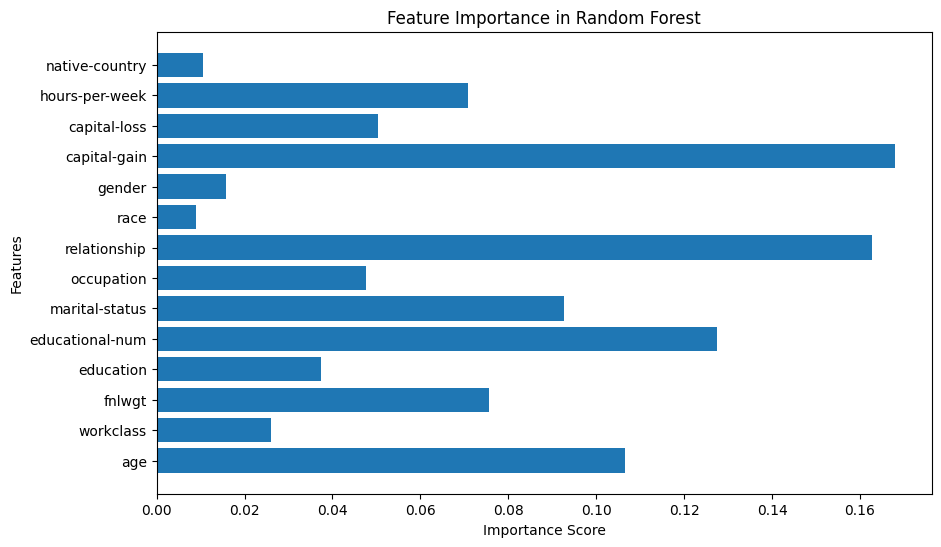

In [ ]:
importances = rf.feature_importances_
feature_names = X.columns
plt.figure(figsize=(10,6))
plt.barh(feature_names, importances)
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance in Random Forest")
plt.show()

The main idea of this experiment is to improve prediction accuracy by combining multiple decision trees instead of relying on a single tree. Random Forest uses bootstrap sampling to create different subsets of data and random feature selection to make trees independent. The final prediction is made using majority voting, which reduces overfitting and improves generalization.